# 13 — Prediksi Jenis Awan pada Citra Baru

Notebook ini digunakan untuk menjalankan inferensi menggunakan model klasifikasi
jenis awan yang telah selesai dilatih dan dievaluasi.

Model dan konfigurasi dibaca dari artefak yang dihasilkan notebook sebelumnya:

- `dataset/processed/model_config.json`;
- `dataset/processed/eval_transform.json`;
- `models/resnet18_gcd_best.pth`.

Tujuan notebook:

1. memuat konfigurasi model;
2. memuat checkpoint terbaik tanpa mengunduh bobot pretrained;
3. memuat pipeline preprocessing evaluation;
4. menerima satu citra atau satu folder citra baru;
5. memvalidasi file citra;
6. menjalankan inferensi menggunakan `torch.inference_mode()`;
7. menampilkan kelas prediksi dan confidence;
8. menampilkan Top-k prediction;
9. menghitung margin confidence dan normalized entropy;
10. menyimpan hasil prediksi ke CSV dan JSON.

Notebook ini tidak:

- melatih ulang model;
- mengubah bobot model;
- membaca label asli citra baru;
- menghitung accuracy atau F1-score;
- menggunakan kembali data test sebagai data operasional.

## Mengimpor Library

Library yang digunakan dibatasi pada kebutuhan inferensi, pembacaan konfigurasi,
validasi citra, visualisasi, dan penyimpanan hasil prediksi.

`ImageFolder`, DataLoader training, optimizer, scheduler, loss function, dan
augmentasi training tidak diperlukan pada tahap ini.

In [1]:
from pathlib import Path
from datetime import datetime

import hashlib
import json
import math
import re
import sys
import warnings

try:
    import albumentations as A
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import timm
    import torch

    from PIL import Image, UnidentifiedImageError
    from IPython.display import display
    from tqdm.auto import tqdm

except ImportError as exc:
    raise ImportError(
        "Dependency prediksi belum lengkap.\n\n"
        "Aktifkan .venv, kemudian jalankan melalui terminal VS Code:\n\n"
        r".\.venv\Scripts\python.exe -m pip install -r requirements.txt"
    ) from exc


pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 150)


print(f"Python          : {sys.version.split()[0]}")
print(f"NumPy           : {np.__version__}")
print(f"Pandas          : {pd.__version__}")
print(f"PyTorch         : {torch.__version__}")
print(f"timm            : {timm.__version__}")
print(f"Albumentations  : {A.__version__}")
print(f"CUDA tersedia   : {torch.cuda.is_available()}")

Python          : 3.11.9
NumPy           : 2.4.6
Pandas          : 3.0.5
PyTorch         : 2.13.0+cpu
timm            : 1.0.28
Albumentations  : 2.0.8
CUDA tersedia   : False


## Menentukan Lokasi Project

Lokasi project ditentukan secara dinamis agar notebook dapat dijalankan melalui
VS Code dari folder utama project maupun dari folder `notebooks`.

Notebook tidak menggunakan path Docker absolut `/app`.

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "notebooks":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR


DATASET_DIR = PROJECT_DIR / "dataset"
RAW_DIR = DATASET_DIR / "raw"
SOURCE_DIR = DATASET_DIR / "source"
PROCESSED_DIR = DATASET_DIR / "processed"

MODELS_DIR = PROJECT_DIR / "models"
LOGS_DIR = PROJECT_DIR / "logs"


MODEL_CONFIG_PATH = (
    PROCESSED_DIR
    / "model_config.json"
)

EVAL_TRANSFORM_PATH = (
    PROCESSED_DIR
    / "eval_transform.json"
)


path_table = pd.DataFrame({
    "Nama": [
        "PROJECT_DIR",
        "PROCESSED_DIR",
        "MODELS_DIR",
        "LOGS_DIR",
        "MODEL_CONFIG_PATH",
        "EVAL_TRANSFORM_PATH",
    ],
    "Path": [
        PROJECT_DIR,
        PROCESSED_DIR,
        MODELS_DIR,
        LOGS_DIR,
        MODEL_CONFIG_PATH,
        EVAL_TRANSFORM_PATH,
    ],
})

path_table["Ada"] = (
    path_table["Path"]
    .map(Path.exists)
)

display(path_table)

,Nama,Path,Ada
0,PROJECT_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification,True
1,PROCESSED_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed,True
2,MODELS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models,True
3,LOGS_DIR,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\logs,True
4,MODEL_CONFIG_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\model_config.json,True
5,EVAL_TRANSFORM_PATH,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\processed\eval_transform.json,True


## Memeriksa Artefak Prediksi

Inferensi memerlukan tiga komponen utama:

1. konfigurasi arsitektur model;
2. pipeline preprocessing evaluation;
3. checkpoint dengan validation loss terbaik.

Checkpoint terakhir tidak digunakan karena checkpoint terbaik merupakan model
yang dipilih berdasarkan performa validation pada tahap training.

In [3]:
required_directories = [
    PROJECT_DIR,
    DATASET_DIR,
    PROCESSED_DIR,
    MODELS_DIR,
    LOGS_DIR,
]

required_files = [
    MODEL_CONFIG_PATH,
    EVAL_TRANSFORM_PATH,
]


missing_directories = [
    path
    for path in required_directories
    if not path.is_dir()
]

missing_files = [
    path
    for path in required_files
    if not path.is_file()
]


if missing_directories:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_directories
    )

    raise FileNotFoundError(
        "Folder berikut belum tersedia:\n"
        f"{formatted_paths}"
    )


if missing_files:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in missing_files
    )

    raise FileNotFoundError(
        "Artefak prediksi berikut belum tersedia:\n"
        f"{formatted_paths}\n\n"
        "Pastikan notebook 05, 07, dan 08 telah dijalankan."
    )


print("Artefak konfigurasi utama tersedia.")

Artefak konfigurasi utama tersedia.


## Membaca Konfigurasi Model

Nama arsitektur, jumlah kelas, pemetaan kelas, ukuran input, dan dropout dibaca
dari `model_config.json`.

Nama serta jumlah kelas tidak ditulis secara manual agar selalu konsisten dengan
model yang telah dilatih.

In [4]:
with MODEL_CONFIG_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    model_config = json.load(file)


required_model_keys = {
    "model_name",
    "num_classes",
    "class_to_idx",
    "input_shape",
}


missing_model_keys = (
    required_model_keys
    - set(model_config.keys())
)


if missing_model_keys:
    raise KeyError(
        "model_config.json belum lengkap. "
        "Kunci yang tidak ditemukan: "
        f"{sorted(missing_model_keys)}"
    )


MODEL_NAME = str(
    model_config["model_name"]
)

NUM_CLASSES = int(
    model_config["num_classes"]
)

CLASS_TO_IDX = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in model_config["class_to_idx"].items()
}

IDX_TO_CLASS = {
    class_idx: class_name
    for class_name, class_idx
    in CLASS_TO_IDX.items()
}


INPUT_CHANNELS, IMAGE_HEIGHT, IMAGE_WIDTH = map(
    int,
    model_config["input_shape"],
)

DROPOUT_RATE = float(
    model_config.get(
        "dropout_rate",
        0.0,
    )
)


expected_indices = list(
    range(NUM_CLASSES)
)

actual_indices = sorted(
    CLASS_TO_IDX.values()
)


if NUM_CLASSES != len(CLASS_TO_IDX):
    raise ValueError(
        "Jumlah kelas tidak konsisten dengan class_to_idx."
    )


if actual_indices != expected_indices:
    raise ValueError(
        "Indeks kelas harus berurutan mulai dari 0.\n"
        f"Diharapkan: {expected_indices}\n"
        f"Ditemukan : {actual_indices}"
    )


SAFE_MODEL_NAME = re.sub(
    r"[^A-Za-z0-9_.-]+",
    "_",
    MODEL_NAME,
)

BEST_CHECKPOINT_PATH = (
    MODELS_DIR
    / f"{SAFE_MODEL_NAME}_gcd_best.pth"
)


configuration_table = pd.DataFrame({
    "Parameter": [
        "Model",
        "Jumlah kelas",
        "Input channel",
        "Tinggi input",
        "Lebar input",
        "Dropout",
        "Checkpoint",
    ],
    "Nilai": [
        MODEL_NAME,
        NUM_CLASSES,
        INPUT_CHANNELS,
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
        DROPOUT_RATE,
        BEST_CHECKPOINT_PATH,
    ],
})

display(configuration_table)

,Parameter,Nilai
0,Model,resnet18
1,Jumlah kelas,7
2,Input channel,3
3,Tinggi input,224
4,Lebar input,224
5,Dropout,0.2
6,Checkpoint,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\models\resnet18_gcd_best.pth


In [5]:
class_mapping_table = pd.DataFrame({
    "class_id": list(IDX_TO_CLASS.keys()),
    "class_name": list(IDX_TO_CLASS.values()),
})

display(class_mapping_table)

print(f"Jumlah kelas model: {NUM_CLASSES}")

,class_id,class_name
0,0,1_cumulus
1,1,2_altocumulus
2,2,3_cirrus
3,3,4_clearsky
4,4,5_stratocumulus
5,5,6_cumulonimbus
6,6,7_mixed


Jumlah kelas model: 7


## Memilih Perangkat Komputasi

GPU CUDA digunakan apabila tersedia. Jika CUDA tidak tersedia, notebook mencoba
menggunakan Apple MPS. CPU digunakan sebagai pilihan terakhir.

Prediksi tetap dapat berjalan menggunakan CPU, tetapi waktu inferensi batch dapat
lebih lama.

In [6]:
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")

elif (
    hasattr(torch.backends, "mps")
    and torch.backends.mps.is_available()
):
    DEVICE = torch.device("mps")

else:
    DEVICE = torch.device("cpu")


device_information = {
    "device": str(DEVICE),
    "cuda_available": torch.cuda.is_available(),
    "cuda_device_count": torch.cuda.device_count(),
}

if DEVICE.type == "cuda":
    device_information["cuda_device_name"] = (
        torch.cuda.get_device_name(0)
    )


display(
    pd.DataFrame(
        device_information.items(),
        columns=["Parameter", "Nilai"],
    )
)

,Parameter,Nilai
0,device,cpu
1,cuda_available,False
2,cuda_device_count,0


## Memuat Checkpoint Terbaik

Checkpoint dimuat ke perangkat yang telah dipilih. Notebook menggunakan
`weights_only=True` pada versi PyTorch yang mendukungnya.

Checkpoint harus berasal dari project sendiri dan dibuat oleh
`08_training_model.ipynb`.

In [7]:
if not BEST_CHECKPOINT_PATH.is_file():
    raise FileNotFoundError(
        "Checkpoint terbaik tidak ditemukan:\n"
        f"{BEST_CHECKPOINT_PATH}\n\n"
        "Jalankan 08_training_model.ipynb terlebih dahulu."
    )


def load_checkpoint(
    checkpoint_path: Path,
    device: torch.device,
) -> dict:
    """
    Memuat checkpoint lokal pada beberapa versi PyTorch.
    """
    try:
        loaded_checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
            weights_only=True,
        )

    except TypeError:
        loaded_checkpoint = torch.load(
            checkpoint_path,
            map_location=device,
        )

    if not isinstance(loaded_checkpoint, dict):
        raise TypeError(
            "Checkpoint harus berupa dictionary."
        )

    return loaded_checkpoint


checkpoint = load_checkpoint(
    checkpoint_path=BEST_CHECKPOINT_PATH,
    device=DEVICE,
)


required_checkpoint_keys = {
    "model_name",
    "model_state_dict",
    "class_to_idx",
    "input_shape",
}


missing_checkpoint_keys = (
    required_checkpoint_keys
    - set(checkpoint.keys())
)


if missing_checkpoint_keys:
    raise KeyError(
        "Checkpoint belum lengkap. "
        "Kunci yang tidak ditemukan: "
        f"{sorted(missing_checkpoint_keys)}"
    )


print("Checkpoint terbaik berhasil dimuat.")
print(f"Fase terbaik : {checkpoint.get('phase', 'tidak tersedia')}")
print(f"Epoch global : {checkpoint.get('global_epoch', 'tidak tersedia')}")
print(f"Disimpan pada: {checkpoint.get('saved_at', 'tidak tersedia')}")

Checkpoint terbaik berhasil dimuat.
Fase terbaik : finetune_all
Epoch global : 25
Disimpan pada: 2026-08-26T02:23:45+07:00


## Memeriksa Konsistensi Checkpoint

Pemeriksaan ini mencegah penggunaan checkpoint dari arsitektur, eksperimen,
jumlah kelas, atau ukuran input yang berbeda.

In [8]:
checkpoint_class_to_idx = {
    str(class_name): int(class_idx)
    for class_name, class_idx
    in checkpoint["class_to_idx"].items()
}

checkpoint_input_shape = tuple(
    map(
        int,
        checkpoint["input_shape"],
    )
)


checkpoint_checks = {
    "Nama model sama": (
        str(checkpoint["model_name"])
        == MODEL_NAME
    ),

    "Pemetaan kelas sama": (
        checkpoint_class_to_idx
        == CLASS_TO_IDX
    ),

    "Ukuran input sama": (
        checkpoint_input_shape
        == (
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        )
    ),

    "Jumlah kelas sama": (
        len(checkpoint_class_to_idx)
        == NUM_CLASSES
    ),

    "Checkpoint bukan hasil test tuning": (
        checkpoint.get(
            "test_data_used",
            False,
        )
        is False
    ),
}


checkpoint_check_table = pd.DataFrame({
    "Pemeriksaan": checkpoint_checks.keys(),
    "Status": [
        "Sesuai" if status else "Tidak sesuai"
        for status in checkpoint_checks.values()
    ],
})

display(checkpoint_check_table)


failed_checkpoint_checks = [
    check_name
    for check_name, status
    in checkpoint_checks.items()
    if not status
]


if failed_checkpoint_checks:
    raise ValueError(
        "Checkpoint tidak konsisten:\n- "
        + "\n- ".join(failed_checkpoint_checks)
    )


print("Checkpoint konsisten dengan model_config.json.")

,Pemeriksaan,Status
0,Nama model sama,Sesuai
1,Pemetaan kelas sama,Sesuai
2,Ukuran input sama,Sesuai
3,Jumlah kelas sama,Sesuai
4,Checkpoint bukan hasil test tuning,Sesuai


Checkpoint konsisten dengan model_config.json.


## Menghitung SHA-256 Checkpoint

SHA-256 digunakan untuk mencatat identitas bobot model. Informasi ini membantu
memastikan hasil prediksi dapat ditelusuri ke checkpoint yang tepat.

In [9]:
def calculate_sha256(
    file_path: Path,
    chunk_size: int = 1024 * 1024,
) -> str:
    """
    Menghitung SHA-256 file tanpa memuat seluruh file ke memori.
    """
    sha256 = hashlib.sha256()

    with file_path.open("rb") as file:
        while chunk := file.read(chunk_size):
            sha256.update(chunk)

    return sha256.hexdigest()


CHECKPOINT_SHA256 = calculate_sha256(
    BEST_CHECKPOINT_PATH
)


print(f"Checkpoint : {BEST_CHECKPOINT_PATH.name}")
print(f"SHA-256    : {CHECKPOINT_SHA256}")

Checkpoint : resnet18_gcd_best.pth
SHA-256    : e9f134760047e2075fe154a0e99c32786e456e6e37790ea1e46e1717af6eb0aa


## Membangun Model Inferensi

Model dibentuk menggunakan `pretrained=False` karena seluruh bobot sudah tersedia
di dalam checkpoint.

Pendekatan ini mencegah unduhan bobot ImageNet dan memastikan model menggunakan
bobot hasil training project.

In [10]:
model = timm.create_model(
    MODEL_NAME,
    pretrained=False,
    num_classes=NUM_CLASSES,
    in_chans=INPUT_CHANNELS,
    drop_rate=DROPOUT_RATE,
)


load_result = model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True,
)


if load_result.missing_keys:
    raise RuntimeError(
        "Parameter checkpoint yang hilang:\n"
        f"{load_result.missing_keys}"
    )


if load_result.unexpected_keys:
    raise RuntimeError(
        "Parameter checkpoint tidak dikenali:\n"
        f"{load_result.unexpected_keys}"
    )


model = model.to(DEVICE)

model.requires_grad_(False)
model.eval()


print(f"Model              : {MODEL_NAME}")
print(f"Device             : {DEVICE}")
print(f"Training mode      : {model.training}")
print("Bobot model        : checkpoint terbaik")
print("Bobot pretrained   : tidak diunduh ulang")
print("Gradient parameter : dinonaktifkan")

Model              : resnet18
Device             : cpu
Training mode      : False
Bobot model        : checkpoint terbaik
Bobot pretrained   : tidak diunduh ulang
Gradient parameter : dinonaktifkan


## Memuat Preprocessing Evaluation

Prediksi citra baru harus menggunakan preprocessing yang sama dengan validation
dan test.

Pipeline training tidak digunakan karena mengandung augmentasi yang dapat
mengubah citra secara acak.

In [11]:
eval_transform_pipeline = A.load(
    str(EVAL_TRANSFORM_PATH),
    data_format="json",
)


print("Pipeline preprocessing prediction:")
print(eval_transform_pipeline)

Pipeline preprocessing prediction:
Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  Normalize(p=1.0, max_pixel_value=255.0, mean=(0.485, 0.456, 0.406), normalization='standard', std=(0.229, 0.224, 0.225)),
  ToTensorV2(p=1.0, transpose_mask=False),
], p=1.0, bbox_params=None, keypoint_params=None, additional_targets={}, is_check_shapes=True)


In [12]:
def load_rgb_image(
    image_path: Path,
) -> Image.Image:
    """
    Membaca citra dan mengubahnya menjadi RGB.
    """
    with Image.open(image_path) as image:
        return image.convert("RGB").copy()


def preprocess_image(
    image_path: Path,
):
    """
    Membaca dan mentransformasi satu citra untuk inferensi.

    Returns
    -------
    tensor:
        Tensor hasil preprocessing dengan bentuk [C, H, W].
    image:
        Citra RGB sebelum preprocessing.
    """
    image = load_rgb_image(image_path)

    image_array = np.array(
        image,
        copy=True,
    )


    transformed = eval_transform_pipeline(
        image=image_array
    )["image"]


    if isinstance(transformed, np.ndarray):
        if transformed.ndim != 3:
            raise ValueError(
                "Output preprocessing NumPy harus memiliki "
                "tiga dimensi."
            )

        transformed = torch.from_numpy(
            np.ascontiguousarray(
                transformed.transpose(2, 0, 1)
            )
        )


    if not torch.is_tensor(transformed):
        raise TypeError(
            "Output preprocessing harus berupa torch.Tensor "
            "atau NumPy array."
        )


    # Mengantisipasi pipeline yang menghasilkan tensor HWC.
    if (
        transformed.ndim == 3
        and transformed.shape[0] != INPUT_CHANNELS
        and transformed.shape[-1] == INPUT_CHANNELS
    ):
        transformed = transformed.permute(
            2,
            0,
            1,
        )


    if transformed.dtype == torch.uint8:
        transformed = (
            transformed.float()
            / 255.0
        )
    else:
        transformed = transformed.float()


    expected_shape = (
        INPUT_CHANNELS,
        IMAGE_HEIGHT,
        IMAGE_WIDTH,
    )


    if tuple(transformed.shape) != expected_shape:
        raise ValueError(
            "Bentuk tensor tidak sesuai konfigurasi model.\n"
            f"Diharapkan: {expected_shape}\n"
            f"Ditemukan : {tuple(transformed.shape)}"
        )


    if not torch.isfinite(transformed).all():
        raise ValueError(
            "Tensor preprocessing mengandung NaN atau infinity."
        )


    if transformed.abs().max().item() > 20:
        warnings.warn(
            "Rentang nilai tensor sangat besar. "
            "Periksa apakah eval_transform.json memuat normalisasi.",
            stacklevel=2,
        )


    return transformed, image

## Menentukan Citra Baru

`PREDICTION_SOURCE` dapat menunjuk ke:

- satu file citra; atau
- satu folder yang berisi beberapa citra.

Gunakan citra baru di luar:

- `dataset/raw`;
- `dataset/source/train`;
- `dataset/source/val`;
- `dataset/source/test`.

Hal ini memisahkan prediksi operasional dari dataset eksperimen.

Ubah hanya nilai `PREDICTION_SOURCE_TEXT`.

In [13]:
# ============================================================
# UBAH PATH BERIKUT SESUAI LOKASI CITRA BARU
# ============================================================

PREDICTION_SOURCE_TEXT = (
    r"C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru"
)

# True  : membaca citra di seluruh subfolder.
# False : hanya membaca isi folder utama.
RECURSIVE_SEARCH = True


if (
    not PREDICTION_SOURCE_TEXT.strip()
    or "NAMA_USER" in PREDICTION_SOURCE_TEXT
):
    raise ValueError(
        "PREDICTION_SOURCE_TEXT belum diubah.\n\n"
        "Masukkan path satu citra atau folder citra baru."
    )


PREDICTION_SOURCE = Path(
    PREDICTION_SOURCE_TEXT
).expanduser()


if not PREDICTION_SOURCE.exists():
    raise FileNotFoundError(
        "Lokasi citra baru tidak ditemukan:\n"
        f"{PREDICTION_SOURCE}"
    )


PREDICTION_SOURCE = (
    PREDICTION_SOURCE
    .resolve()
)


print(f"Sumber prediksi : {PREDICTION_SOURCE}")
print(f"Berupa file     : {PREDICTION_SOURCE.is_file()}")
print(f"Berupa folder   : {PREDICTION_SOURCE.is_dir()}")

Sumber prediksi : C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru
Berupa file     : False
Berupa folder   : True


In [14]:
def path_is_inside(
    candidate_path: Path,
    parent_path: Path,
) -> bool:
    """
    Memeriksa apakah candidate_path berada di dalam parent_path.
    """
    try:
        candidate_path.resolve().relative_to(
            parent_path.resolve()
        )
        return True

    except ValueError:
        return False


protected_dataset_locations = [
    RAW_DIR,
    SOURCE_DIR,
]


protected_matches = [
    protected_path
    for protected_path in protected_dataset_locations
    if (
        protected_path.exists()
        and path_is_inside(
            PREDICTION_SOURCE,
            protected_path,
        )
    )
]


if protected_matches:
    formatted_paths = "\n".join(
        f"- {path}"
        for path in protected_matches
    )

    raise ValueError(
        "Sumber prediksi berada di dalam dataset eksperimen:\n"
        f"{formatted_paths}\n\n"
        "Gunakan citra baru yang berada di luar dataset/raw "
        "dan dataset/source."
    )


print(
    "Sumber prediksi terpisah dari dataset raw dan source."
)

Sumber prediksi terpisah dari dataset raw dan source.


## Mengumpulkan File Citra

Jika sumber berupa folder, seluruh file dengan ekstensi citra yang didukung akan
dikumpulkan. Urutan file diurutkan berdasarkan path agar hasil prediksi tetap
konsisten.

In [15]:
SUPPORTED_IMAGE_EXTENSIONS = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".tif",
    ".tiff",
    ".webp",
}


def collect_image_paths(
    source_path: Path,
    recursive: bool = True,
) -> list[Path]:
    """
    Mengumpulkan satu atau beberapa file citra.
    """
    if source_path.is_file():
        if (
            source_path.suffix.lower()
            not in SUPPORTED_IMAGE_EXTENSIONS
        ):
            raise ValueError(
                "Ekstensi file tidak didukung: "
                f"{source_path.suffix}"
            )

        return [source_path]


    if source_path.is_dir():
        iterator = (
            source_path.rglob("*")
            if recursive
            else source_path.glob("*")
        )

        image_paths = sorted(
            path.resolve()
            for path in iterator
            if (
                path.is_file()
                and path.suffix.lower()
                in SUPPORTED_IMAGE_EXTENSIONS
            )
        )

        return image_paths


    raise ValueError(
        "Sumber prediksi harus berupa file atau folder."
    )


image_paths = collect_image_paths(
    source_path=PREDICTION_SOURCE,
    recursive=RECURSIVE_SEARCH,
)


if not image_paths:
    raise FileNotFoundError(
        "Tidak ditemukan file citra yang didukung pada:\n"
        f"{PREDICTION_SOURCE}"
    )


print(f"Jumlah kandidat citra: {len(image_paths):,}")
print("\nLima file pertama:")

for path in image_paths[:5]:
    print(f"- {path}")

Jumlah kandidat citra: 220

Lima file pertama:
- C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\1.jpg
- C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\10.jpg
- C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\100.jpg
- C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\101.jpg
- C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\102.jpg


## Memvalidasi File Citra

Validasi dilakukan sebelum inferensi untuk mendeteksi file rusak, tidak terbaca,
atau file yang memiliki ekstensi citra tetapi isi datanya tidak valid.

File tidak valid tidak diteruskan ke model.

In [16]:
validation_records = []


for image_path in tqdm(
    image_paths,
    desc="Validasi citra",
):
    record = {
        "image_path": str(image_path),
        "file_name": image_path.name,
        "is_valid": False,
        "format": None,
        "mode": None,
        "width": None,
        "height": None,
        "file_size_bytes": (
            image_path.stat().st_size
        ),
        "error": None,
    }

    try:
        with Image.open(image_path) as image:
            image.verify()

        with Image.open(image_path) as image:
            record["format"] = image.format
            record["mode"] = image.mode
            record["width"] = int(image.width)
            record["height"] = int(image.height)

        record["is_valid"] = True

    except (
        UnidentifiedImageError,
        OSError,
        ValueError,
    ) as exc:
        record["error"] = str(exc)

    validation_records.append(record)


image_validation_df = pd.DataFrame(
    validation_records
)


validation_summary = (
    image_validation_df
    .groupby(
        "is_valid",
        dropna=False,
    )
    .size()
    .rename("jumlah")
    .reset_index()
)


display(validation_summary)
display(image_validation_df.head(10))

Validasi citra:   0%|          | 0/220 [00:00<?, ?it/s]

,is_valid,jumlah
0,True,220


,image_path,file_name,is_valid,format,mode,width,height,file_size_bytes,error
0,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\1.jpg,1.jpg,True,JPEG,RGB,400,400,54176,None
1,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\10.jpg,10.jpg,True,JPEG,RGB,400,400,39512,None
2,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\100.jpg,100.jpg,True,JPEG,RGB,400,400,16312,None
3,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\101.jpg,101.jpg,True,JPEG,RGB,400,400,55319,None
4,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\102.jpg,102.jpg,True,JPEG,RGB,256,256,9553,None
5,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\103.jpg,103.jpg,True,JPEG,RGB,400,400,54595,None
6,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\104.jpg,104.jpg,True,JPEG,RGB,400,400,15377,None
7,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\105.jpg,105.jpg,True,JPEG,RGB,400,400,61662,None
8,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\106.jpg,106.jpg,True,JPEG,RGB,400,400,7973,None
9,C:\Users\jardm\Documents\n8n-logsiswaparalayang\cloud-classification\dataset\citra_baru\107.jpg,107.jpg,True,JPEG,RGB,400,400,44231,None


In [17]:
valid_image_paths = [
    Path(image_path)
    for image_path
    in image_validation_df.loc[
        image_validation_df["is_valid"],
        "image_path",
    ]
]


invalid_image_df = (
    image_validation_df
    .loc[
        ~image_validation_df["is_valid"]
    ]
    .copy()
)


if not invalid_image_df.empty:
    warnings.warn(
        f"{len(invalid_image_df):,} file tidak valid "
        "dan tidak akan diprediksi.",
        stacklevel=2,
    )

    display(
        invalid_image_df[
            [
                "file_name",
                "image_path",
                "error",
            ]
        ]
    )


if not valid_image_paths:
    raise RuntimeError(
        "Tidak ada citra valid yang dapat diprediksi."
    )


print(
    f"Citra valid untuk prediksi: "
    f"{len(valid_image_paths):,}"
)

Citra valid untuk prediksi: 220


## Memeriksa Determinisme Preprocessing

Citra yang sama diproses dua kali. Hasil tensor harus identik karena pipeline
evaluation tidak seharusnya menggunakan augmentasi acak.

In [18]:
sample_tensor_1, sample_image = preprocess_image(
    valid_image_paths[0]
)

sample_tensor_2, _ = preprocess_image(
    valid_image_paths[0]
)


PREPROCESSING_DETERMINISTIC = torch.allclose(
    sample_tensor_1,
    sample_tensor_2,
    atol=1e-7,
    rtol=0.0,
)


preprocessing_check_table = pd.DataFrame({
    "Parameter": [
        "File pemeriksaan",
        "Ukuran citra asli",
        "Bentuk tensor",
        "Tipe tensor",
        "Nilai minimum",
        "Nilai maksimum",
        "Preprocessing deterministik",
    ],
    "Nilai": [
        valid_image_paths[0].name,
        sample_image.size,
        tuple(sample_tensor_1.shape),
        str(sample_tensor_1.dtype),
        float(sample_tensor_1.min().item()),
        float(sample_tensor_1.max().item()),
        PREPROCESSING_DETERMINISTIC,
    ],
})

display(preprocessing_check_table)


if not PREPROCESSING_DETERMINISTIC:
    raise RuntimeError(
        "Pipeline evaluation menghasilkan tensor berbeda "
        "untuk citra yang sama. Periksa eval_transform.json."
    )


print("Pipeline preprocessing bersifat deterministik.")

,Parameter,Nilai
0,File pemeriksaan,1.jpg
1,Ukuran citra asli,"(400, 400)"
2,Bentuk tensor,"(3, 224, 224)"
3,Tipe tensor,torch.float32
4,Nilai minimum,-2.117904
5,Nilai maksimum,2.378562
6,Preprocessing deterministik,True


Pipeline preprocessing bersifat deterministik.


## Konfigurasi Inferensi

`TOP_K` menentukan jumlah kelas dengan confidence tertinggi yang ditampilkan.

Confidence merupakan nilai softmax model. Nilai tersebut tidak boleh langsung
diartikan sebagai peluang bahwa prediksi pasti benar, terutama jika kalibrasi
model belum memenuhi kebutuhan operasional.

In [19]:
PREDICTION_BATCH_SIZE = 16

TOP_K = min(
    3,
    NUM_CLASSES,
)

MAX_PREVIEW_IMAGES = 6


if PREDICTION_BATCH_SIZE < 1:
    raise ValueError(
        "PREDICTION_BATCH_SIZE minimal 1."
    )


if TOP_K < 1:
    raise ValueError(
        "TOP_K minimal 1."
    )


inference_configuration_table = pd.DataFrame({
    "Parameter": [
        "Batch size",
        "Top-k",
        "Maksimum preview",
        "Device",
        "Jumlah citra",
    ],
    "Nilai": [
        PREDICTION_BATCH_SIZE,
        TOP_K,
        MAX_PREVIEW_IMAGES,
        str(DEVICE),
        len(valid_image_paths),
    ],
})

display(inference_configuration_table)

,Parameter,Nilai
0,Batch size,16
1,Top-k,3
2,Maksimum preview,6
3,Device,cpu
4,Jumlah citra,220


## Fungsi Prediksi Batch

Fungsi menjalankan prediksi secara bertahap agar banyak citra tidak dimuat ke
memori sekaligus.

Informasi yang dihasilkan meliputi:

- kelas prediksi;
- confidence tertinggi;
- kelas peringkat kedua;
- selisih confidence Top-1 dan Top-2;
- normalized entropy;
- Top-k prediction;
- confidence seluruh kelas;
- SHA-256 citra.

In [20]:
def normalized_entropy(
    probabilities: torch.Tensor,
) -> float:
    """
    Menghitung entropy yang dinormalisasi ke rentang 0–1.

    Nilai mendekati 0:
        distribusi confidence lebih terkonsentrasi.

    Nilai mendekati 1:
        confidence lebih tersebar pada beberapa kelas.
    """
    probabilities = probabilities.clamp_min(
        1e-12
    )

    entropy = -torch.sum(
        probabilities
        * torch.log(probabilities)
    )

    maximum_entropy = math.log(
        len(probabilities)
    )

    return float(
        entropy.item()
        / maximum_entropy
    )


def predict_images(
    model: torch.nn.Module,
    image_paths: list[Path],
    batch_size: int,
) -> pd.DataFrame:
    """
    Menjalankan inferensi pada daftar citra.
    """
    prediction_records = []


    for batch_start in tqdm(
        range(
            0,
            len(image_paths),
            batch_size,
        ),
        desc="Prediksi citra",
    ):
        batch_paths = image_paths[
            batch_start:
            batch_start + batch_size
        ]

        batch_tensors = []
        batch_metadata = []


        for image_path in batch_paths:
            tensor, original_image = preprocess_image(
                image_path
            )

            batch_tensors.append(tensor)

            batch_metadata.append({
                "image_path": image_path,
                "file_name": image_path.name,
                "original_width": original_image.width,
                "original_height": original_image.height,
                "file_size_bytes": (
                    image_path.stat().st_size
                ),
                "image_sha256": calculate_sha256(
                    image_path
                ),
            })


        image_batch = torch.stack(
            batch_tensors
        ).to(
            DEVICE,
            non_blocking=(
                DEVICE.type == "cuda"
            ),
        )


        with torch.inference_mode():
            logits = model(image_batch)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )


        if logits.shape != (
            len(batch_paths),
            NUM_CLASSES,
        ):
            raise ValueError(
                "Bentuk output model tidak sesuai.\n"
                f"Diharapkan: "
                f"({len(batch_paths)}, {NUM_CLASSES})\n"
                f"Ditemukan : {tuple(logits.shape)}"
            )


        top_values, top_indices = torch.topk(
            probabilities,
            k=TOP_K,
            dim=1,
        )


        probabilities_cpu = (
            probabilities
            .detach()
            .cpu()
        )

        top_values_cpu = (
            top_values
            .detach()
            .cpu()
        )

        top_indices_cpu = (
            top_indices
            .detach()
            .cpu()
        )


        for sample_index, metadata in enumerate(
            batch_metadata
        ):
            sample_probabilities = (
                probabilities_cpu[
                    sample_index
                ]
            )

            top_k_records = [
                {
                    "rank": rank + 1,
                    "class_id": int(class_idx),
                    "class_name": (
                        IDX_TO_CLASS[
                            int(class_idx)
                        ]
                    ),
                    "confidence": float(
                        confidence
                    ),
                }
                for rank, (
                    confidence,
                    class_idx,
                )
                in enumerate(
                    zip(
                        top_values_cpu[
                            sample_index
                        ].tolist(),
                        top_indices_cpu[
                            sample_index
                        ].tolist(),
                    )
                )
            ]


            probability_mapping = {
                IDX_TO_CLASS[class_idx]: float(
                    sample_probabilities[
                        class_idx
                    ].item()
                )
                for class_idx
                in range(NUM_CLASSES)
            }


            predicted_class_id = int(
                top_indices_cpu[
                    sample_index,
                    0,
                ].item()
            )

            prediction_confidence = float(
                top_values_cpu[
                    sample_index,
                    0,
                ].item()
            )


            if NUM_CLASSES >= 2:
                second_class_id = int(
                    top_indices_cpu[
                        sample_index,
                        1,
                    ].item()
                )

                second_confidence = float(
                    top_values_cpu[
                        sample_index,
                        1,
                    ].item()
                )

                confidence_margin = (
                    prediction_confidence
                    - second_confidence
                )

                second_class_name = (
                    IDX_TO_CLASS[
                        second_class_id
                    ]
                )

            else:
                second_class_id = None
                second_class_name = None
                second_confidence = None
                confidence_margin = None


            prediction_records.append({
                "predicted_at": (
                    datetime.now()
                    .astimezone()
                    .isoformat(timespec="seconds")
                ),

                "image_path": str(
                    metadata["image_path"]
                ),

                "file_name": (
                    metadata["file_name"]
                ),

                "original_width": (
                    metadata["original_width"]
                ),

                "original_height": (
                    metadata["original_height"]
                ),

                "file_size_bytes": (
                    metadata["file_size_bytes"]
                ),

                "image_sha256": (
                    metadata["image_sha256"]
                ),

                "predicted_class_id": (
                    predicted_class_id
                ),

                "predicted_class": (
                    IDX_TO_CLASS[
                        predicted_class_id
                    ]
                ),

                "confidence": (
                    prediction_confidence
                ),

                "second_class_id": (
                    second_class_id
                ),

                "second_class": (
                    second_class_name
                ),

                "second_confidence": (
                    second_confidence
                ),

                "confidence_margin": (
                    confidence_margin
                ),

                "normalized_entropy": (
                    normalized_entropy(
                        sample_probabilities
                    )
                ),

                "top_k_json": json.dumps(
                    top_k_records,
                    ensure_ascii=False,
                ),

                "probabilities_json": json.dumps(
                    probability_mapping,
                    ensure_ascii=False,
                ),

                "model_name": MODEL_NAME,

                "checkpoint_sha256": (
                    CHECKPOINT_SHA256
                ),
            })


    return pd.DataFrame(
        prediction_records
    )

In [21]:
prediction_df = predict_images(
    model=model,
    image_paths=valid_image_paths,
    batch_size=PREDICTION_BATCH_SIZE,
)


if prediction_df.empty:
    raise RuntimeError(
        "Model tidak menghasilkan prediksi."
    )


display_columns = [
    "file_name",
    "predicted_class",
    "confidence",
    "second_class",
    "second_confidence",
    "confidence_margin",
    "normalized_entropy",
]


display(
    prediction_df[
        display_columns
    ]
    .style
    .format({
        "confidence": "{:.4%}",
        "second_confidence": "{:.4%}",
        "confidence_margin": "{:.4f}",
        "normalized_entropy": "{:.4f}",
    })
)


print(
    f"Prediksi selesai untuk "
    f"{len(prediction_df):,} citra."
)

Prediksi citra:   0%|          | 0/14 [00:00<?, ?it/s]

,file_name,predicted_class,confidence,second_class,second_confidence,confidence_margin,normalized_entropy
0,1.jpg,6_cumulonimbus,35.5270%,1_cumulus,27.9402%,0.0759,0.8087
1,10.jpg,1_cumulus,74.7924%,2_altocumulus,11.7348%,0.6306,0.4503
2,100.jpg,7_mixed,78.4052%,1_cumulus,18.1448%,0.6026,0.3428
3,101.jpg,1_cumulus,33.8949%,7_mixed,31.1111%,0.0278,0.7433
4,102.jpg,6_cumulonimbus,69.4028%,7_mixed,10.3542%,0.5905,0.5701
5,103.jpg,7_mixed,78.8892%,1_cumulus,13.7391%,0.6515,0.3895
6,104.jpg,5_stratocumulus,42.3594%,3_cirrus,16.0826%,0.2628,0.8078
7,105.jpg,3_cirrus,47.9717%,7_mixed,46.0267%,0.0195,0.4925
8,106.jpg,3_cirrus,62.2442%,4_clearsky,19.2748%,0.4297,0.5965
9,107.jpg,7_mixed,30.1292%,6_cumulonimbus,26.6506%,0.0348,0.7891


Prediksi selesai untuk 220 citra.


## Memeriksa Probabilitas Softmax

Jumlah confidence seluruh kelas untuk setiap citra harus mendekati satu.
Pemeriksaan ini memastikan konversi logits menjadi softmax berjalan dengan benar.

In [22]:
probability_sums = prediction_df[
    "probabilities_json"
].map(
    lambda value: sum(
        json.loads(value).values()
    )
)


probability_check_df = pd.DataFrame({
    "file_name": prediction_df["file_name"],
    "probability_sum": probability_sums,
    "valid": np.isclose(
        probability_sums,
        1.0,
        atol=1e-6,
    ),
})


display(probability_check_df.head(10))


if not probability_check_df["valid"].all():
    raise ValueError(
        "Ditemukan jumlah probabilitas yang tidak mendekati 1."
    )


print("Seluruh distribusi softmax valid.")

,file_name,probability_sum,valid
0,1.jpg,1.0,True
1,10.jpg,1.0,True
2,100.jpg,1.0,True
3,101.jpg,1.0,True
4,102.jpg,1.0,True
5,103.jpg,1.0,True
6,104.jpg,1.0,True
7,105.jpg,1.0,True
8,106.jpg,1.0,True
9,107.jpg,1.0,True


Seluruh distribusi softmax valid.


## Visualisasi Prediksi

Visualisasi menampilkan citra asli dan Top-k confidence. Jika jumlah citra lebih
banyak dari batas preview, citra dengan confidence paling rendah ditampilkan
terlebih dahulu agar hasil yang lebih meragukan lebih mudah diperiksa.

In [23]:
def display_prediction(
    prediction_row: pd.Series,
) -> None:
    """
    Menampilkan citra dan Top-k prediction.
    """
    image_path = Path(
        prediction_row["image_path"]
    )

    image = load_rgb_image(
        image_path
    )

    top_k_data = json.loads(
        prediction_row["top_k_json"]
    )


    class_names = [
        record["class_name"]
        for record in top_k_data
    ]

    confidences = [
        record["confidence"]
        for record in top_k_data
    ]


    figure, axes = plt.subplots(
        1,
        2,
        figsize=(12, 5),
    )


    axes[0].imshow(image)

    axes[0].set_title(
        (
            f"Prediksi: "
            f"{prediction_row['predicted_class']}\n"
            f"Confidence: "
            f"{prediction_row['confidence']:.2%}"
        )
    )

    axes[0].axis("off")


    plot_names = class_names[::-1]
    plot_confidences = confidences[::-1]


    axes[1].barh(
        plot_names,
        plot_confidences,
        color="steelblue",
    )

    axes[1].set_xlim(0.0, 1.0)
    axes[1].set_xlabel("Confidence")
    axes[1].set_title("Top-k Prediction")


    for index, confidence in enumerate(
        plot_confidences
    ):
        axes[1].text(
            min(confidence + 0.015, 0.95),
            index,
            f"{confidence:.2%}",
            va="center",
        )


    figure.suptitle(
        prediction_row["file_name"],
        fontsize=14,
    )

    plt.tight_layout()
    plt.show()

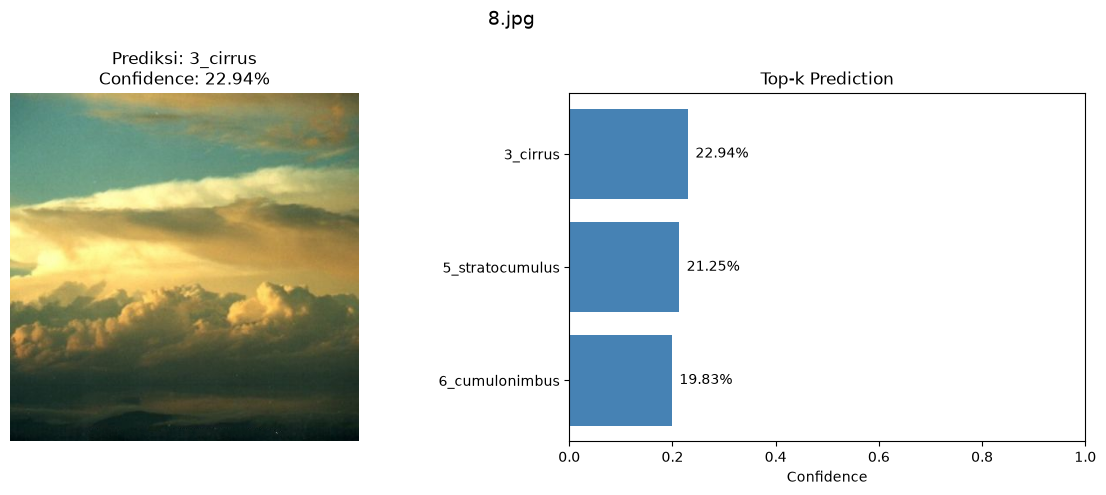

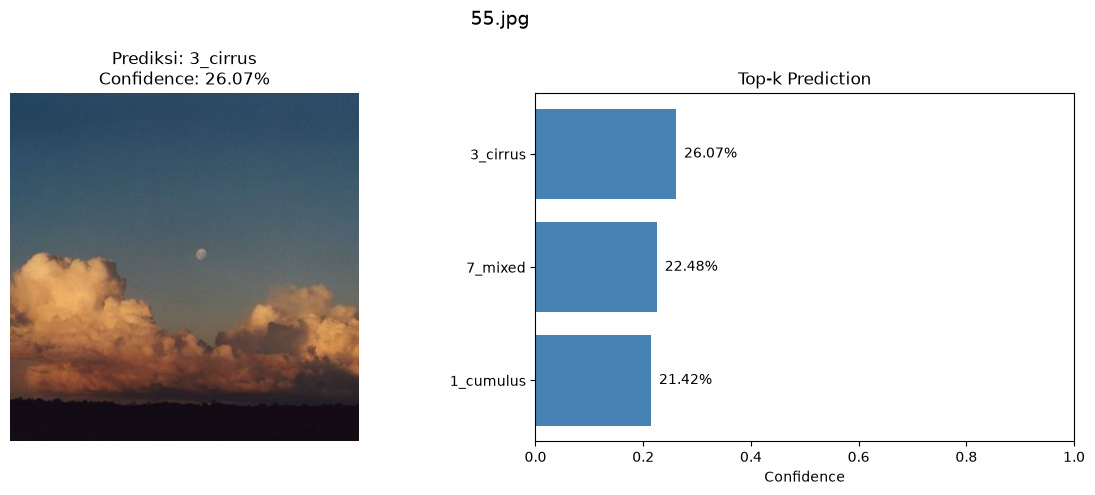

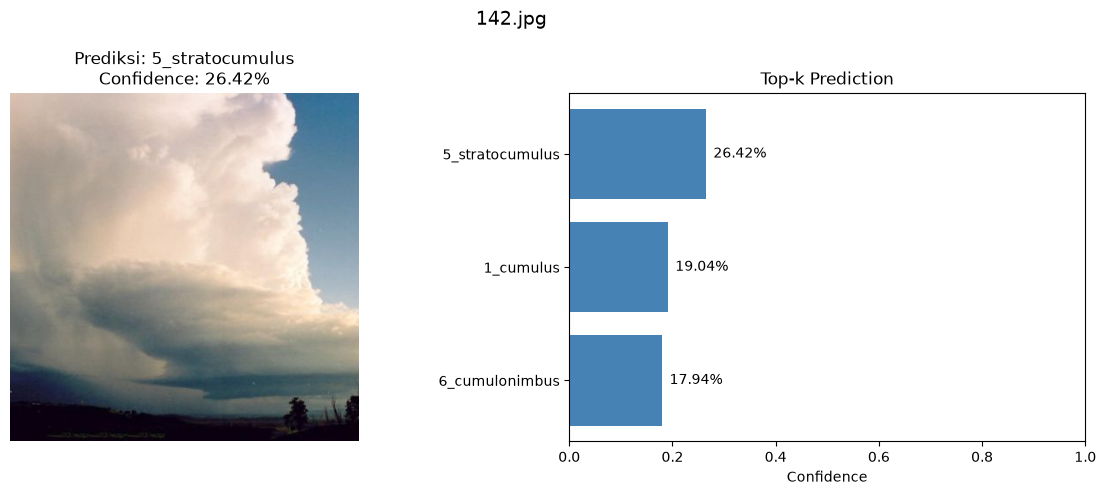

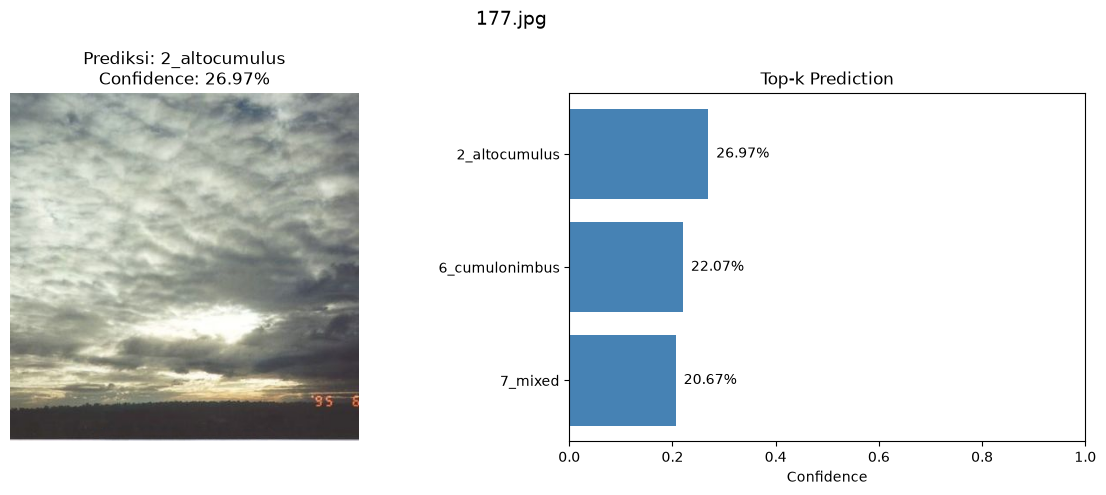

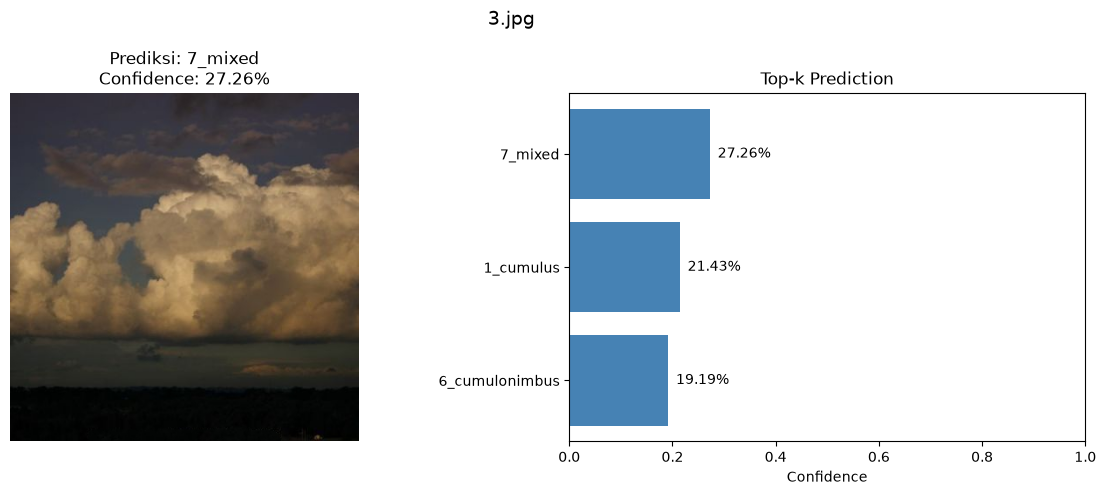

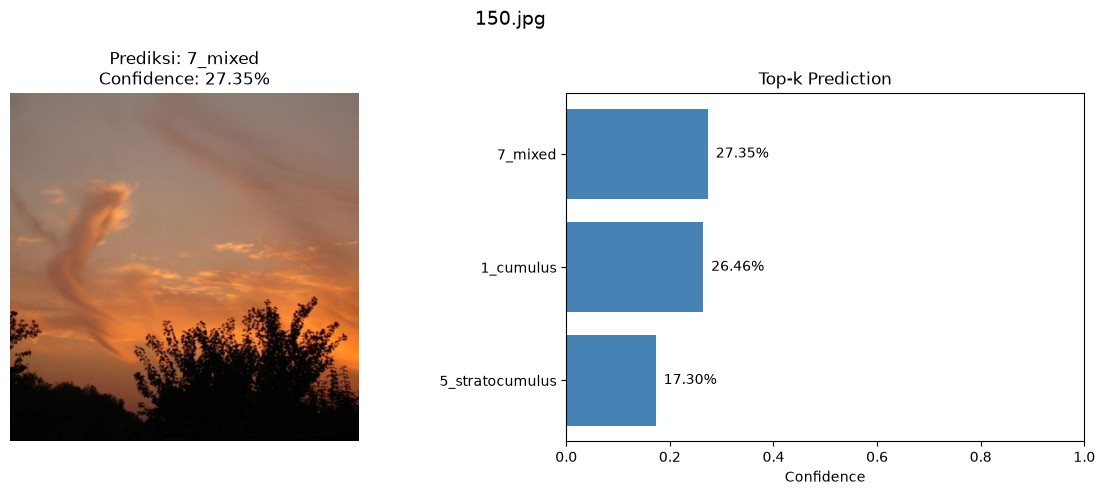

In [24]:
preview_count = min(
    MAX_PREVIEW_IMAGES,
    len(prediction_df),
)


preview_prediction_df = (
    prediction_df
    .sort_values(
        "confidence",
        ascending=True,
    )
    .head(preview_count)
)


for _, prediction_row in (
    preview_prediction_df.iterrows()
):
    display_prediction(
        prediction_row
    )

## Ringkasan Prediksi Batch

Ringkasan ini hanya menunjukkan distribusi keluaran model terhadap citra baru.
Jumlah prediksi per kelas bukan ukuran distribusi populasi awan dan bukan
pengganti evaluasi menggunakan label ground truth.

In [25]:
prediction_class_summary_df = (
    prediction_df
    .groupby(
        [
            "predicted_class_id",
            "predicted_class",
        ],
        as_index=False,
    )
    .agg(
        jumlah_prediksi=(
            "file_name",
            "count",
        ),
        mean_confidence=(
            "confidence",
            "mean",
        ),
        min_confidence=(
            "confidence",
            "min",
        ),
        max_confidence=(
            "confidence",
            "max",
        ),
        mean_normalized_entropy=(
            "normalized_entropy",
            "mean",
        ),
    )
    .sort_values(
        "predicted_class_id"
    )
)


display(
    prediction_class_summary_df
    .style
    .format({
        "mean_confidence": "{:.4%}",
        "min_confidence": "{:.4%}",
        "max_confidence": "{:.4%}",
        "mean_normalized_entropy": "{:.4f}",
    })
)

,predicted_class_id,predicted_class,jumlah_prediksi,mean_confidence,min_confidence,max_confidence,mean_normalized_entropy
0,0,1_cumulus,22,57.7221%,29.5695%,95.1260%,0.5935
1,1,2_altocumulus,21,65.2986%,26.9682%,91.9340%,0.5045
2,2,3_cirrus,79,61.9781%,22.9438%,93.6247%,0.5776
3,3,4_clearsky,2,66.2491%,61.6045%,70.8937%,0.6020
4,4,5_stratocumulus,19,44.6151%,26.4223%,65.6399%,0.7587
5,5,6_cumulonimbus,29,54.4295%,28.7151%,72.8676%,0.6775
6,6,7_mixed,48,58.9850%,27.2632%,98.0342%,0.5835


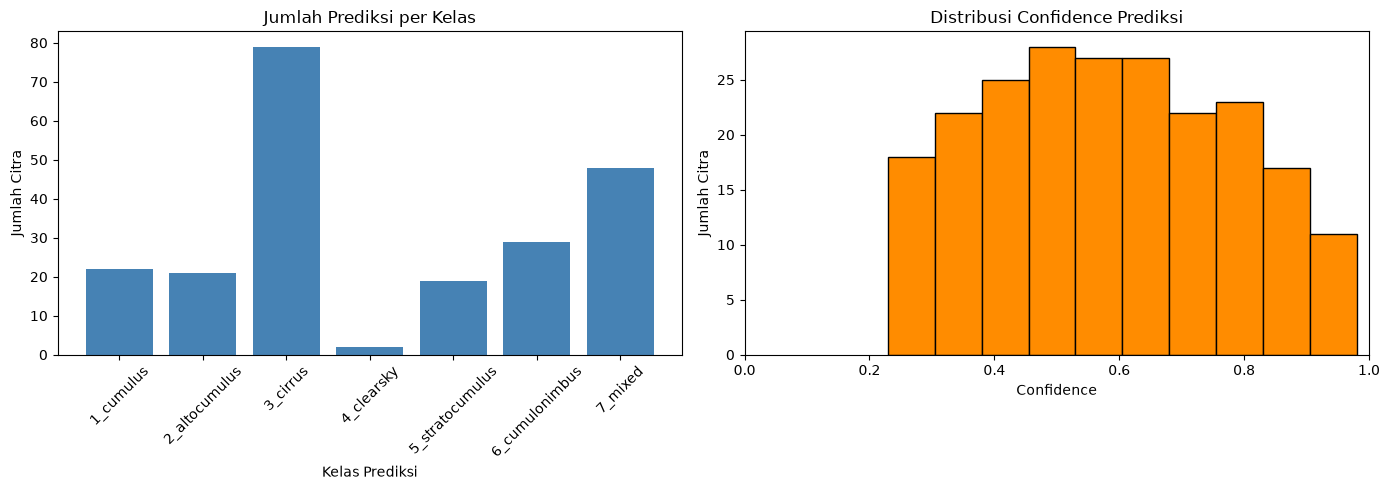

In [26]:
figure, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
)


axes[0].bar(
    prediction_class_summary_df[
        "predicted_class"
    ],
    prediction_class_summary_df[
        "jumlah_prediksi"
    ],
    color="steelblue",
)

axes[0].set_title(
    "Jumlah Prediksi per Kelas"
)

axes[0].set_xlabel(
    "Kelas Prediksi"
)

axes[0].set_ylabel(
    "Jumlah Citra"
)

axes[0].tick_params(
    axis="x",
    rotation=45,
)


axes[1].hist(
    prediction_df["confidence"],
    bins=min(
        10,
        max(
            1,
            len(prediction_df),
        ),
    ),
    color="darkorange",
    edgecolor="black",
)

axes[1].set_title(
    "Distribusi Confidence Prediksi"
)

axes[1].set_xlabel(
    "Confidence"
)

axes[1].set_ylabel(
    "Jumlah Citra"
)

axes[1].set_xlim(
    0.0,
    1.0,
)


plt.tight_layout()
plt.show()

In [27]:
NUMBER_OF_REVIEW_SAMPLES = min(
    10,
    len(prediction_df),
)


review_priority_df = (
    prediction_df
    .sort_values(
        by=[
            "confidence",
            "normalized_entropy",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .head(
        NUMBER_OF_REVIEW_SAMPLES
    )
)


review_columns = [
    "file_name",
    "predicted_class",
    "confidence",
    "second_class",
    "second_confidence",
    "confidence_margin",
    "normalized_entropy",
]


display(
    review_priority_df[
        review_columns
    ]
    .style
    .format({
        "confidence": "{:.4%}",
        "second_confidence": "{:.4%}",
        "confidence_margin": "{:.4f}",
        "normalized_entropy": "{:.4f}",
    })
)


print(
    "Tabel diurutkan berdasarkan confidence terendah. "
    "Peninjauan tidak berarti prediksi tersebut pasti salah."
)

,file_name,predicted_class,confidence,second_class,second_confidence,confidence_margin,normalized_entropy
198,8.jpg,3_cirrus,22.9438%,5_stratocumulus,21.2471%,0.0170,0.8910
171,55.jpg,3_cirrus,26.0673%,7_mixed,22.4830%,0.0358,0.8879
48,142.jpg,5_stratocumulus,26.4223%,1_cumulus,19.0432%,0.0738,0.8899
86,177.jpg,2_altocumulus,26.9682%,6_cumulonimbus,22.0686%,0.0490,0.8630
143,3.jpg,7_mixed,27.2632%,1_cumulus,21.4345%,0.0583,0.8991
57,150.jpg,7_mixed,27.3470%,1_cumulus,26.4631%,0.0088,0.8851
130,216.jpg,5_stratocumulus,27.4852%,3_cirrus,21.8180%,0.0567,0.8607
55,149.jpg,7_mixed,27.5096%,3_cirrus,26.9904%,0.0052,0.8262
95,185.jpg,3_cirrus,27.5500%,7_mixed,25.3032%,0.0225,0.9192
29,125.jpg,5_stratocumulus,27.9521%,6_cumulonimbus,26.1452%,0.0181,0.8438


Tabel diurutkan berdasarkan confidence terendah. Peninjauan tidak berarti prediksi tersebut pasti salah.


## Menyimpan Hasil Prediksi

Hasil disimpan di dalam subfolder `logs/prediction_runs/`. Citra asli tidak
disalin sehingga tidak terjadi duplikasi data.

Artefak yang dihasilkan:

- `prediction_results.csv`;
- `prediction_results.json`;
- `prediction_class_summary.csv`;
- `image_validation.csv`;
- `prediction_run_summary.json`.

In [28]:
RUN_ID = (
    datetime.now()
    .astimezone()
    .strftime("%Y%m%d_%H%M%S")
)


PREDICTION_OUTPUT_DIR = (
    LOGS_DIR
    / "prediction_runs"
    / f"{SAFE_MODEL_NAME}_{RUN_ID}"
)


PREDICTION_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=False,
)


PREDICTION_CSV_PATH = (
    PREDICTION_OUTPUT_DIR
    / "prediction_results.csv"
)

PREDICTION_JSON_PATH = (
    PREDICTION_OUTPUT_DIR
    / "prediction_results.json"
)

PREDICTION_CLASS_SUMMARY_PATH = (
    PREDICTION_OUTPUT_DIR
    / "prediction_class_summary.csv"
)

IMAGE_VALIDATION_PATH = (
    PREDICTION_OUTPUT_DIR
    / "image_validation.csv"
)

PREDICTION_RUN_SUMMARY_PATH = (
    PREDICTION_OUTPUT_DIR
    / "prediction_run_summary.json"
)


prediction_df.to_csv(
    PREDICTION_CSV_PATH,
    index=False,
    encoding="utf-8-sig",
)


prediction_class_summary_df.to_csv(
    PREDICTION_CLASS_SUMMARY_PATH,
    index=False,
    encoding="utf-8-sig",
)


image_validation_df.to_csv(
    IMAGE_VALIDATION_PATH,
    index=False,
    encoding="utf-8-sig",
)


prediction_json_records = []

for record in prediction_df.to_dict(
    orient="records"
):
    record["top_k"] = json.loads(
        record.pop("top_k_json")
    )

    record["probabilities"] = json.loads(
        record.pop("probabilities_json")
    )

    prediction_json_records.append(
        record
    )


with PREDICTION_JSON_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        prediction_json_records,
        file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


print(
    "Hasil prediksi utama berhasil disimpan."
)

Hasil prediksi utama berhasil disimpan.


In [29]:
prediction_run_summary = {
    "created_at": (
        datetime.now()
        .astimezone()
        .isoformat(timespec="seconds")
    ),

    "stage": "13_prediksi_citra_baru",
    "run_id": RUN_ID,

    "inference": {
        "training_performed": False,
        "model_weights_updated": False,
        "ground_truth_used": False,
        "evaluation_metrics_calculated": False,
        "torch_inference_mode_used": True,
    },

    "model": {
        "model_name": MODEL_NAME,
        "num_classes": NUM_CLASSES,
        "class_to_idx": CLASS_TO_IDX,
        "input_shape": [
            INPUT_CHANNELS,
            IMAGE_HEIGHT,
            IMAGE_WIDTH,
        ],
        "dropout_rate": DROPOUT_RATE,
        "device": str(DEVICE),
    },

    "checkpoint": {
        "path": str(
            BEST_CHECKPOINT_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "sha256": CHECKPOINT_SHA256,
        "phase": checkpoint.get("phase"),
        "global_epoch": checkpoint.get(
            "global_epoch"
        ),
    },

    "preprocessing": {
        "eval_transform": str(
            EVAL_TRANSFORM_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "deterministic": (
            PREPROCESSING_DETERMINISTIC
        ),
    },

    "input": {
        "source": str(PREDICTION_SOURCE),
        "recursive_search": RECURSIVE_SEARCH,
        "candidate_images": int(
            len(image_paths)
        ),
        "valid_images": int(
            len(valid_image_paths)
        ),
        "invalid_images": int(
            len(invalid_image_df)
        ),
    },

    "prediction": {
        "batch_size": (
            PREDICTION_BATCH_SIZE
        ),
        "top_k": TOP_K,
        "number_of_predictions": int(
            len(prediction_df)
        ),
        "mean_confidence": float(
            prediction_df[
                "confidence"
            ].mean()
        ),
        "mean_normalized_entropy": float(
            prediction_df[
                "normalized_entropy"
            ].mean()
        ),
    },

    "output_artifacts": {
        "prediction_csv": str(
            PREDICTION_CSV_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "prediction_json": str(
            PREDICTION_JSON_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "class_summary_csv": str(
            PREDICTION_CLASS_SUMMARY_PATH.relative_to(
                PROJECT_DIR
            )
        ),
        "image_validation_csv": str(
            IMAGE_VALIDATION_PATH.relative_to(
                PROJECT_DIR
            )
        ),
    },
}


with PREDICTION_RUN_SUMMARY_PATH.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        prediction_run_summary,
        file,
        indent=2,
        ensure_ascii=False,
        allow_nan=False,
    )


print(
    "Ringkasan proses disimpan:\n"
    f"{PREDICTION_RUN_SUMMARY_PATH.relative_to(PROJECT_DIR)}"
)

Ringkasan proses disimpan:
logs\prediction_runs\resnet18_20260826_162654\prediction_run_summary.json


## Pemeriksaan Hasil Akhir

Pemeriksaan akhir memastikan bahwa:

- model berada pada mode evaluation;
- parameter tidak memiliki gradient;
- checkpoint konsisten;
- seluruh citra valid memperoleh prediksi;
- probabilitas softmax valid;
- preprocessing deterministik;
- hasil CSV dan JSON tersimpan;
- dataset mentah tidak dimodifikasi.

In [30]:
required_output_files = [
    PREDICTION_CSV_PATH,
    PREDICTION_JSON_PATH,
    PREDICTION_CLASS_SUMMARY_PATH,
    IMAGE_VALIDATION_PATH,
    PREDICTION_RUN_SUMMARY_PATH,
]


final_checks = {
    "Model berada pada mode evaluation": (
        model.training is False
    ),

    "Parameter model tidak memiliki gradient": all(
        parameter.grad is None
        for parameter in model.parameters()
    ),

    "Checkpoint konsisten": all(
        checkpoint_checks.values()
    ),

    "Preprocessing deterministik": (
        PREPROCESSING_DETERMINISTIC
    ),

    "Seluruh citra valid diprediksi": (
        len(prediction_df)
        == len(valid_image_paths)
    ),

    "Jumlah probabilitas valid": (
        probability_check_df[
            "valid"
        ].all()
    ),

    "Predicted class tidak kosong": (
        prediction_df[
            "predicted_class"
        ].notna().all()
    ),

    "Confidence berada pada rentang valid": (
        prediction_df[
            "confidence"
        ]
        .between(
            0.0,
            1.0,
            inclusive="both",
        )
        .all()
    ),

    "Entropy berada pada rentang valid": (
        prediction_df[
            "normalized_entropy"
        ]
        .between(
            0.0,
            1.0,
            inclusive="both",
        )
        .all()
    ),

    "Seluruh artefak output tersedia": all(
        path.is_file()
        for path in required_output_files
    ),

    "Sumber bukan dataset raw": (
        not path_is_inside(
            PREDICTION_SOURCE,
            RAW_DIR,
        )
    ),

    "Sumber bukan dataset source": (
        not path_is_inside(
            PREDICTION_SOURCE,
            SOURCE_DIR,
        )
    ),
}


final_check_table = pd.DataFrame({
    "Pemeriksaan": final_checks.keys(),
    "Status": [
        "Berhasil" if status else "Gagal"
        for status in final_checks.values()
    ],
})


display(final_check_table)


failed_final_checks = [
    check_name
    for check_name, status
    in final_checks.items()
    if not status
]


if failed_final_checks:
    raise RuntimeError(
        "Pemeriksaan akhir prediksi gagal:\n- "
        + "\n- ".join(failed_final_checks)
    )


print(
    "Seluruh pemeriksaan akhir prediksi berhasil."
)

,Pemeriksaan,Status
0,Model berada pada mode evaluation,Berhasil
1,Parameter model tidak memiliki gradient,Berhasil
2,Checkpoint konsisten,Berhasil
3,Preprocessing deterministik,Berhasil
4,Seluruh citra valid diprediksi,Berhasil
5,Jumlah probabilitas valid,Berhasil
6,Predicted class tidak kosong,Berhasil
7,Confidence berada pada rentang valid,Berhasil
8,Entropy berada pada rentang valid,Berhasil
9,Seluruh artefak output tersedia,Berhasil


Seluruh pemeriksaan akhir prediksi berhasil.


In [31]:
lowest_confidence_row = (
    prediction_df
    .sort_values(
        "confidence",
        ascending=True,
    )
    .iloc[0]
)


highest_confidence_row = (
    prediction_df
    .sort_values(
        "confidence",
        ascending=False,
    )
    .iloc[0]
)


print("=" * 78)
print("PREDIKSI CITRA BARU SELESAI")
print("=" * 78)

print(
    f"Model                    : "
    f"{MODEL_NAME}"
)

print(
    f"Checkpoint               : "
    f"{BEST_CHECKPOINT_PATH.relative_to(PROJECT_DIR)}"
)

print(
    f"Device                   : "
    f"{DEVICE}"
)

print(
    f"Jumlah kandidat citra    : "
    f"{len(image_paths):,}"
)

print(
    f"Jumlah citra valid       : "
    f"{len(valid_image_paths):,}"
)

print(
    f"Jumlah citra tidak valid : "
    f"{len(invalid_image_df):,}"
)

print(
    f"Jumlah hasil prediksi    : "
    f"{len(prediction_df):,}"
)

print(
    f"Rata-rata confidence     : "
    f"{prediction_df['confidence'].mean():.4%}"
)

print(
    f"Confidence tertinggi     : "
    f"{highest_confidence_row['file_name']} — "
    f"{highest_confidence_row['predicted_class']} "
    f"({highest_confidence_row['confidence']:.4%})"
)

print(
    f"Confidence terendah      : "
    f"{lowest_confidence_row['file_name']} — "
    f"{lowest_confidence_row['predicted_class']} "
    f"({lowest_confidence_row['confidence']:.4%})"
)

print(
    f"Folder hasil             : "
    f"{PREDICTION_OUTPUT_DIR.relative_to(PROJECT_DIR)}"
)

print("Training dijalankan      : Tidak")
print("Bobot model diperbarui   : Tidak")
print("Ground truth digunakan   : Tidak")
print("Metrik evaluasi dihitung : Tidak")

print("=" * 78)

PREDIKSI CITRA BARU SELESAI
Model                    : resnet18
Checkpoint               : models\resnet18_gcd_best.pth
Device                   : cpu
Jumlah kandidat citra    : 220
Jumlah citra valid       : 220
Jumlah citra tidak valid : 0
Jumlah hasil prediksi    : 220
Rata-rata confidence     : 58.7607%
Confidence tertinggi     : 212.jpg — 7_mixed (98.0342%)
Confidence terendah      : 8.jpg — 3_cirrus (22.9438%)
Folder hasil             : logs\prediction_runs\resnet18_20260826_162654
Training dijalankan      : Tidak
Bobot model diperbarui   : Tidak
Ground truth digunakan   : Tidak
Metrik evaluasi dihitung : Tidak


## Interpretasi Hasil Prediksi

### Kelas prediksi

`predicted_class` merupakan kelas dengan nilai softmax tertinggi. Kelas tersebut
menjadi keputusan utama model terhadap citra yang diberikan.

### Confidence

`confidence` merupakan nilai softmax untuk kelas peringkat pertama. Confidence
tinggi menunjukkan keluaran model lebih terkonsentrasi pada satu kelas, tetapi
tidak membuktikan bahwa prediksi pasti benar.

### Confidence margin

`confidence_margin` merupakan selisih confidence kelas peringkat pertama dan
kedua. Margin yang kecil menunjukkan bahwa model menghasilkan skor yang
berdekatan untuk dua kelas.

### Normalized entropy

Normalized entropy menggambarkan penyebaran confidence pada seluruh kelas.
Nilai mendekati nol menunjukkan distribusi yang lebih terkonsentrasi, sedangkan
nilai mendekati satu menunjukkan distribusi confidence yang lebih merata.

### Batas interpretasi

Notebook tidak memiliki label asli citra baru. Oleh karena itu, notebook tidak
menghitung accuracy, precision, recall, atau F1-score. Kebenaran prediksi hanya
dapat ditentukan melalui anotasi ground truth oleh pihak yang memiliki
kompetensi dalam identifikasi jenis awan.

Citra dengan confidence rendah, margin kecil, atau entropy tinggi sebaiknya
diprioritaskan untuk pemeriksaan manusia. Kondisi tersebut tidak otomatis
membuktikan bahwa prediksi salah.

## Kesimpulan

Tahap prediksi citra baru telah dilaksanakan menggunakan checkpoint terbaik dari
tahap training.

Pemeriksaan memastikan bahwa:

1. arsitektur model dibaca dari `model_config.json`;
2. pemetaan kelas tidak ditulis secara manual;
3. checkpoint berasal dari model yang sama;
4. pipeline evaluation digunakan kembali;
5. bobot pretrained tidak diunduh ulang;
6. model berada pada mode evaluation;
7. gradient dan pembaruan bobot dinonaktifkan;
8. citra baru dipisahkan dari dataset raw dan source;
9. file citra divalidasi sebelum inferensi;
10. preprocessing bersifat deterministik;
11. confidence seluruh kelas berjumlah mendekati satu;
12. hasil prediksi disimpan dalam format CSV dan JSON;
13. identitas checkpoint dan citra dicatat menggunakan SHA-256;
14. tidak dilakukan penghitungan metrik tanpa ground truth;
15. dataset asli tidak dimodifikasi.

Hasil notebook dapat digunakan sebagai dasar implementasi fungsi inferensi yang
lebih stabil pada `src/predict.py`. Pemindahan kode ke folder `src/` sebaiknya
dilakukan setelah alur prediksi satu citra dan batch telah diuji menggunakan
beberapa citra baru.